# 02 — EDA del dataset filtrato e processato v1

Questo notebook esplora il dataset finale ricostruito a partire da:

- dataset filtrato in Parquet;
- output JSONL del processing LLM;
- annotazioni aggiunte al primo messaggio `user`: `natural_language_text` e `code_text`;
- label top-level: `detected_language` e `task_category`.

L'obiettivo è verificare qualità, distribuzioni e coerenza del dataset prima delle analisi successive della tesi.


## 0. Setup e configurazione

Questa sezione centralizza path, import e funzioni generali. Il notebook prova a riconoscere automaticamente la root del progetto: può essere eseguito sia dalla directory principale sia da `notebooks/`.


In [7]:
# Se necessario, eseguire una sola volta:
# %pip install -q pandas numpy matplotlib pyarrow tqdm pygments
# Opzionale, per tentare inferenza più avanzata dei linguaggi nei code block senza fence language:
# %pip install -q guesslang

from __future__ import annotations

import json
import re
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from tqdm.auto import tqdm

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from pygments.lexers import guess_lexer
    PYGMENTS_AVAILABLE = True
except Exception:
    PYGMENTS_AVAILABLE = False

try:
    from guesslang import Guess
    GUESSLANG_AVAILABLE = True
    GUESSLANG_MODEL = Guess()
except Exception:
    GUESSLANG_AVAILABLE = False
    GUESSLANG_MODEL = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 180)

RANDOM_SEED = 42
TOP_N = 25


def find_project_root() -> Path:
    """Trova una root plausibile del progetto cercando la directory data/."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root()
FINAL_DATASET_DIR = PROJECT_ROOT / "data" / "final" / "v1"
PROCESSED_JSONL_DIR = PROJECT_ROOT / "data" / "processed" / "v1"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda_final_v1"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for directory in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FINAL_DATASET_DIR: {FINAL_DATASET_DIR}")
print(f"PROCESSED_JSONL_DIR: {PROCESSED_JSONL_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"PYGMENTS_AVAILABLE: {PYGMENTS_AVAILABLE}")
print(f"GUESSLANG_AVAILABLE: {GUESSLANG_AVAILABLE}")


PROJECT_ROOT: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis
FINAL_DATASET_DIR: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\data\final\v1
PROCESSED_JSONL_DIR: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\data\processed\v1
OUTPUT_DIR: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\outputs\eda_final_v1
PYGMENTS_AVAILABLE: True
GUESSLANG_AVAILABLE: False


## 1. Caricamento dataset

Carico tutti i file Parquet presenti in `data/final/v1`. Se vuoi usare un'altra directory, modifica `FINAL_DATASET_DIR` nella cella di setup.


In [8]:
def read_parquet_directory(directory: Path) -> pd.DataFrame:
    parquet_files = sorted(directory.glob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found in: {directory}")

    frames = []
    for path in tqdm(parquet_files, desc="Loading final parquet files"):
        frames.append(pd.read_parquet(path))

    return pd.concat(frames, ignore_index=True)


df = read_parquet_directory(FINAL_DATASET_DIR)

print(f"Record caricati: {len(df):,}")
print(f"Colonne: {len(df.columns)}")
display(df.head(3))


Loading final parquet files: 100%|██████████| 7/7 [00:02<00:00,  2.80it/s]


Record caricati: 61,835
Colonne: 7


,conversation_id,model,turn,conversation,snippet_turns,detected_language,task_category
0,84b76971d297c9d3b33edc6e6380ab4f,gpt-4-0314,1,"[[{'role': 'user', 'content': 'Write a script for Blender 3D version 3.5, so that you can align objects at the same distance from each other.', 'timestamp': None, 'natural_lang...",[1],EN,CODE_GENERATION
1,bcdc32b84c55fbc6ed31b1432f36c8e4,gpt-4-0314,1,"[[{'role': 'user', 'content': 'the problem here that background ""#1B2827"" in "".language-option"" doesn't want to go full height after ""#night-mode-toggle"" switch: <style> body, ...",[1],EN,BUG_FIXING
2,a52b628b634b185d78f2e10cd5e5efcd,gpt-3.5-turbo-0301,1,"[[{'role': 'user', 'content': 'Можно ли заменить ios::binary и сделать более простым код? // Function to save data from an array of cars into a file void save_data(Car* cars, i...",[1],RU,REFACTORING


In [9]:
# Carico anche gli output JSONL grezzi del processing, se disponibili.
# Servono soprattutto per controllare gli status, che non sono stati inclusi nel dataset finale pulito.

def read_processed_jsonl_directory(directory: Path) -> pd.DataFrame:
    jsonl_files = sorted(directory.glob("*.jsonl"))
    if not jsonl_files:
        print(f"Nessun JSONL trovato in: {directory}")
        return pd.DataFrame()

    rows = []
    invalid_rows = 0

    for path in tqdm(jsonl_files, desc="Loading processed JSONL files"):
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    invalid_rows += 1

    if invalid_rows:
        print(f"Righe JSONL non valide ignorate: {invalid_rows:,}")

    return pd.DataFrame(rows)


processed_df = read_processed_jsonl_directory(PROCESSED_JSONL_DIR)
print(f"Record processed caricati: {len(processed_df):,}")

if not processed_df.empty:
    display(processed_df.head(3))


Loading processed JSONL files: 100%|██████████| 7/7 [00:04<00:00,  1.54it/s]


Record processed caricati: 61,835


,processing_key,conversation_id,source_file,row_index,user_prompt_original,natural_language_text,code_text,contains_code,task_category,is_code_generation,detected_language,code_nl_status,task_lang_status,overall_status,overall_error
0,84b76971d297c9d3b33edc6e6380ab4f,84b76971d297c9d3b33edc6e6380ab4f,part_000.parquet,0,"Write a script for Blender 3D version 3.5, so that you can align objects at the same distance from each other.","Write a script for Blender 3D version 3.5, so that you can align objects at the same distance from each other.",,False,CODE_GENERATION,True,EN,ok,ok,ok,None
1,a52b628b634b185d78f2e10cd5e5efcd,a52b628b634b185d78f2e10cd5e5efcd,part_000.parquet,2,"Можно ли заменить ios::binary и сделать более простым код? // Function to save data from an array of cars into a file\nvoid save_data(Car* cars, int n) {\nofstream file(""cars.d...",Можно ли заменить ios::binary и сделать более простым код? // Function to save data from an array of cars into a file,"void save_data(Car* cars, int n) {\nofstream file(""cars.dat"" , ios::binary);\nif (!file) {\ncout << ""Unable to create file."" << endl;\nreturn;\n}\nfor (int i = 0; i < n; i++) {...",True,REFACTORING,True,RU,ok,ok,ok,None
2,f037e5089daf75a37f3c1c36ad8819d7,f037e5089daf75a37f3c1c36ad8819d7,part_000.parquet,5,"Update the following code const [questionnaire, categories] = await prisma.$transaction([\n prisma.questionnaire.findFirst({\n orderBy: [{ startDate: 'desc' }]...","Update the following code const [questionnaire, categories] = await prisma.$transaction([\n ]); so that questionnaires with current date greater than endDate are not retu...","prisma.questionnaire.findFirst({\n orderBy: [{ startDate: 'desc' }],\n where: {\n ...filter,\n approved: true,\n disabled: fa...",True,CODE_MODIFICATION,True,EN,ok,ok,ok,None


## 2. Funzioni di supporto per conversazioni e grafici

Le conversazioni sono strutture annidate. Le funzioni seguenti estraggono messaggi `user` e `assistant`, verificano le annotazioni e producono grafici riutilizzabili.


In [10]:
def safe_to_python(obj: Any) -> Any:
    """Converte array/list/dict provenienti da parquet in oggetti Python semplici."""
    if obj is None:
        return None
    if hasattr(obj, "tolist") and not isinstance(obj, (str, bytes)):
        try:
            return safe_to_python(obj.tolist())
        except Exception:
            pass
    if isinstance(obj, list):
        return [safe_to_python(x) for x in obj]
    if isinstance(obj, tuple):
        return [safe_to_python(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): safe_to_python(v) for k, v in obj.items()}
    return obj


def iter_messages(conversation: Any) -> Iterable[dict[str, Any]]:
    """Itera tutti i messaggi in una conversazione annidata."""
    conversation = safe_to_python(conversation)

    def _walk(obj: Any):
        if isinstance(obj, dict):
            if "role" in obj and "content" in obj:
                yield obj
            else:
                for value in obj.values():
                    yield from _walk(value)
        elif isinstance(obj, list):
            for item in obj:
                yield from _walk(item)

    yield from _walk(conversation)


def get_messages_by_role(conversation: Any, role: str) -> list[dict[str, Any]]:
    role = role.lower().strip()
    return [m for m in iter_messages(conversation) if str(m.get("role", "")).lower().strip() == role]


def first_user_message(conversation: Any) -> dict[str, Any] | None:
    users = get_messages_by_role(conversation, "user")
    return users[0] if users else None


def assistant_text(conversation: Any) -> str:
    assistants = get_messages_by_role(conversation, "assistant")
    return "\n\n".join(str(m.get("content", "")) for m in assistants if m.get("content") is not None)


def add_user_annotation_columns(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    user_messages = out["conversation"].map(first_user_message)
    out["user_content"] = user_messages.map(lambda m: m.get("content", "") if isinstance(m, dict) else "")
    out["user_natural_language_text"] = user_messages.map(lambda m: m.get("natural_language_text", "") if isinstance(m, dict) else "")
    out["user_code_text"] = user_messages.map(lambda m: m.get("code_text", "") if isinstance(m, dict) else "")
    out["user_has_nl_annotation"] = out["user_natural_language_text"].fillna("").astype(str).str.len() > 0
    out["user_has_code_annotation"] = out["user_code_text"].fillna("").astype(str).str.len() > 0
    out["assistant_text"] = out["conversation"].map(assistant_text)
    out["assistant_text_len"] = out["assistant_text"].fillna("").astype(str).str.len()
    out["user_content_len"] = out["user_content"].fillna("").astype(str).str.len()
    out["user_nl_len"] = out["user_natural_language_text"].fillna("").astype(str).str.len()
    out["user_code_len"] = out["user_code_text"].fillna("").astype(str).str.len()
    return out


df = add_user_annotation_columns(df)


def save_table(table: pd.DataFrame, name: str) -> None:
    table.to_csv(TABLES_DIR / f"{name}.csv", index=False)


def plot_barh_counts(
    counts: pd.Series,
    title: str,
    xlabel: str = "Conteggio",
    top_n: int = TOP_N,
    figsize: tuple[int, int] = (11, 7),
    save_name: str | None = None,
) -> pd.DataFrame:
    plot_counts = counts.dropna().astype(int).head(top_n)
    plot_df = plot_counts.rename_axis("value").reset_index(name="count")
    plot_df["percentage"] = plot_df["count"] / max(plot_df["count"].sum(), 1)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df["count"])
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["value"].astype(str))
    ax.invert_yaxis()
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    max_count = plot_df["count"].max() if not plot_df.empty else 0
    for i, row in plot_df.iterrows():
        ax.text(row["count"] + max_count * 0.01, i, f"{row['count']:,} ({row['percentage']:.1%})", va="center", fontsize=9)

    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    if save_name:
        fig.savefig(FIGURES_DIR / save_name, dpi=220, bbox_inches="tight")
    plt.show()

    return plot_df


def plot_vertical_counts(
    counts: pd.Series,
    title: str,
    xlabel: str,
    ylabel: str = "Conteggio",
    top_n: int = TOP_N,
    figsize: tuple[int, int] = (12, 6),
    save_name: str | None = None,
) -> pd.DataFrame:
    plot_counts = counts.dropna().astype(int).head(top_n)
    plot_df = plot_counts.rename_axis("value").reset_index(name="count")

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(plot_df))
    ax.bar(x, plot_df["count"])
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["value"].astype(str), rotation=45, ha="right")
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    if save_name:
        fig.savefig(FIGURES_DIR / save_name, dpi=220, bbox_inches="tight")
    plt.show()

    return plot_df


## 3. Controlli generali

Verifico schema, duplicati, valori mancanti, lunghezze dei testi e presenza delle annotazioni nel primo messaggio `user`.


In [11]:
expected_columns = [
    "conversation_id",
    "model",
    "turn",
    "conversation",
    "snippet_turns",
    "detected_language",
    "task_category",
]

schema_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[col].dtype) for col in df.columns],
    "missing": [int(df[col].isna().sum()) for col in df.columns],
    "missing_pct": [float(df[col].isna().mean()) for col in df.columns],
    "is_expected": [col in expected_columns for col in df.columns],
})

general_summary = pd.DataFrame({
    "metric": [
        "n_records",
        "n_columns",
        "n_unique_conversation_id",
        "duplicate_conversation_id",
        "missing_conversation_id",
        "missing_conversation",
        "missing_detected_language",
        "missing_task_category",
        "records_with_user_nl_annotation",
        "records_with_user_code_annotation",
        "records_with_assistant_text",
    ],
    "value": [
        len(df),
        len(df.columns),
        df["conversation_id"].nunique(dropna=True) if "conversation_id" in df.columns else None,
        int(df["conversation_id"].duplicated().sum()) if "conversation_id" in df.columns else None,
        int(df["conversation_id"].isna().sum()) if "conversation_id" in df.columns else None,
        int(df["conversation"].isna().sum()) if "conversation" in df.columns else None,
        int(df["detected_language"].isna().sum()) if "detected_language" in df.columns else None,
        int(df["task_category"].isna().sum()) if "task_category" in df.columns else None,
        int(df["user_has_nl_annotation"].sum()),
        int(df["user_has_code_annotation"].sum()),
        int((df["assistant_text_len"] > 0).sum()),
    ],
})

display(general_summary)
display(schema_summary)

save_table(general_summary, "general_summary")
save_table(schema_summary, "schema_summary")


,metric,value
0,n_records,61835
1,n_columns,17
2,n_unique_conversation_id,61835
3,duplicate_conversation_id,0
4,missing_conversation_id,0
5,missing_conversation,0
6,missing_detected_language,0
7,missing_task_category,0
8,records_with_user_nl_annotation,58916
9,records_with_user_code_annotation,42692


,column,dtype,missing,missing_pct,is_expected
0,conversation_id,str,0,0.0,True
1,model,str,0,0.0,True
2,turn,int64,0,0.0,True
3,conversation,object,0,0.0,True
4,snippet_turns,object,0,0.0,True
5,detected_language,str,0,0.0,True
6,task_category,str,0,0.0,True
7,user_content,str,0,0.0,False
8,user_natural_language_text,str,0,0.0,False
9,user_code_text,str,0,0.0,False


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
user_content_len,61835.0,7228.134277,21134.298244,7.0,26.0,44.0,65.0,191.0,1427.0,5233.0,17244.8,32056.3,94322.30,784259.0
user_nl_len,61835.0,1140.323377,6384.415916,0.0,0.0,7.0,30.0,68.0,183.0,688.0,1986.6,3431.0,15877.42,472671.0
user_code_len,61835.0,6042.079664,18846.906402,0.0,0.0,0.0,0.0,0.0,512.0,3993.0,14951.0,28927.8,86313.86,730150.0
assistant_text_len,61835.0,5717.316973,8203.472572,9.0,97.0,519.0,782.0,1491.0,3025.0,6655.0,13175.0,19263.6,41025.96,150094.0


C:\Users\franc\AppData\Local\Temp\ipykernel_15144\3864431880.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


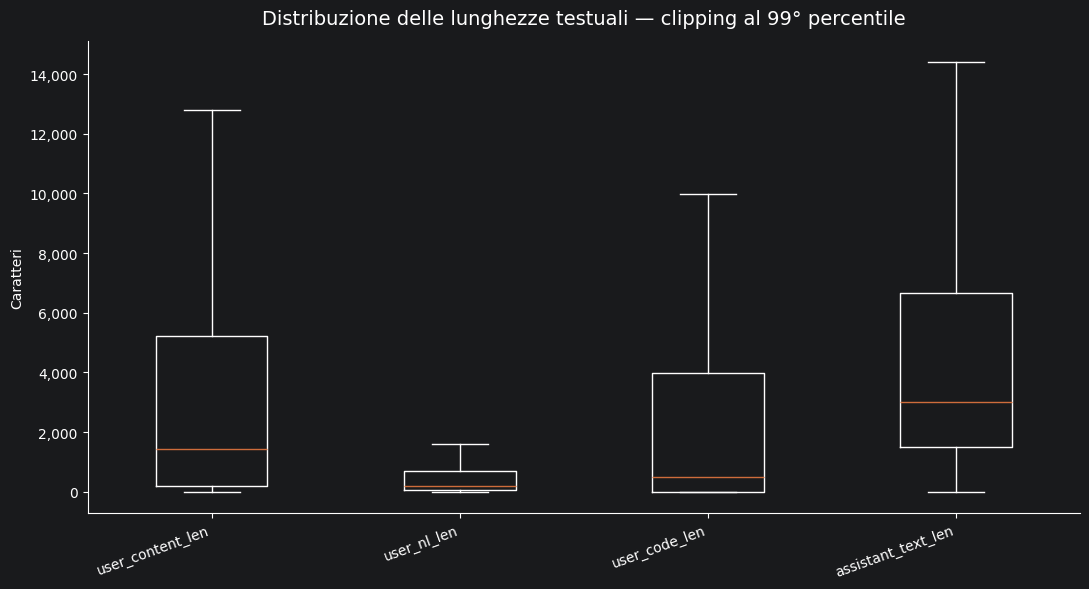

In [12]:
length_cols = ["user_content_len", "user_nl_len", "user_code_len", "assistant_text_len"]

length_summary = df[length_cols].describe(
    percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]
).T

display(length_summary)
save_table(length_summary.reset_index(names="field"), "text_length_summary")

fig, ax = plt.subplots(figsize=(11, 6))

upper_bounds = df[length_cols].quantile(.99)
plot_data = df[length_cols].clip(upper=upper_bounds, axis=1)

ax.boxplot(
    [plot_data[col].dropna() for col in plot_data.columns],
    labels=plot_data.columns,
    showfliers=False
)

ax.set_title("Distribuzione delle lunghezze testuali — clipping al 99° percentile", fontsize=14, pad=12)
ax.set_ylabel("Caratteri")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_length_boxplot.png", dpi=220, bbox_inches="tight")
plt.show()


## 4. Controlli su status

Gli status non sono nel dataset finale pulito, quindi vengono letti dagli output JSONL originali in `data/processed/v1`. Se la directory non è disponibile, questa sezione viene saltata.


,status_column,status,count,percentage
0,overall_status,ok,61835,1.0
1,code_nl_status,ok,61835,1.0
2,task_lang_status,ok,61835,1.0


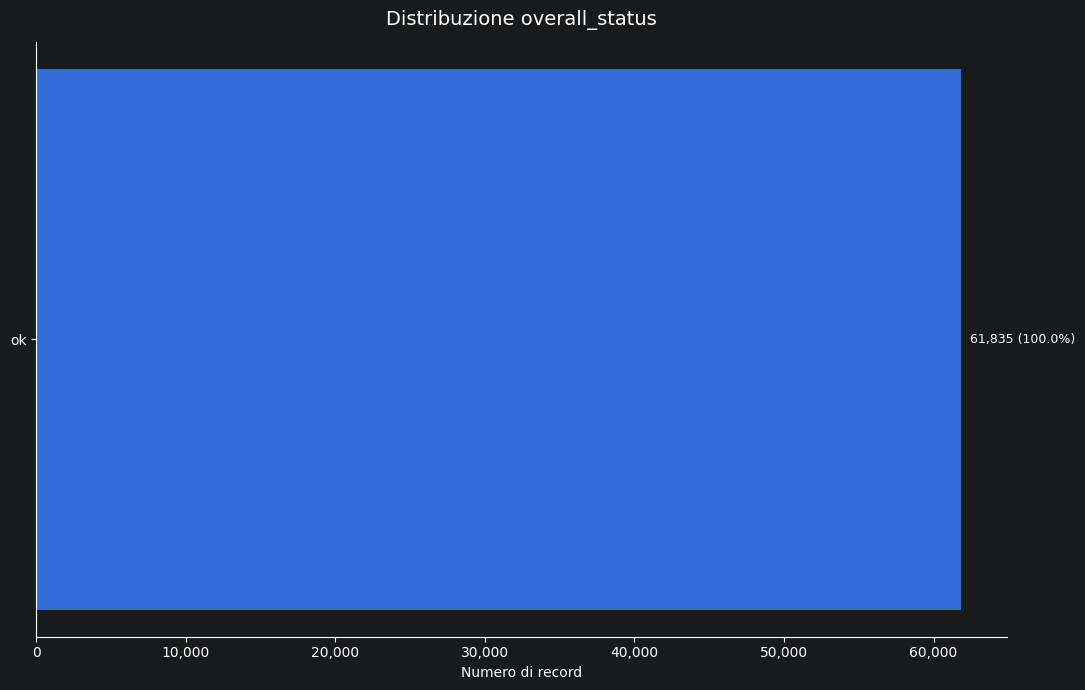

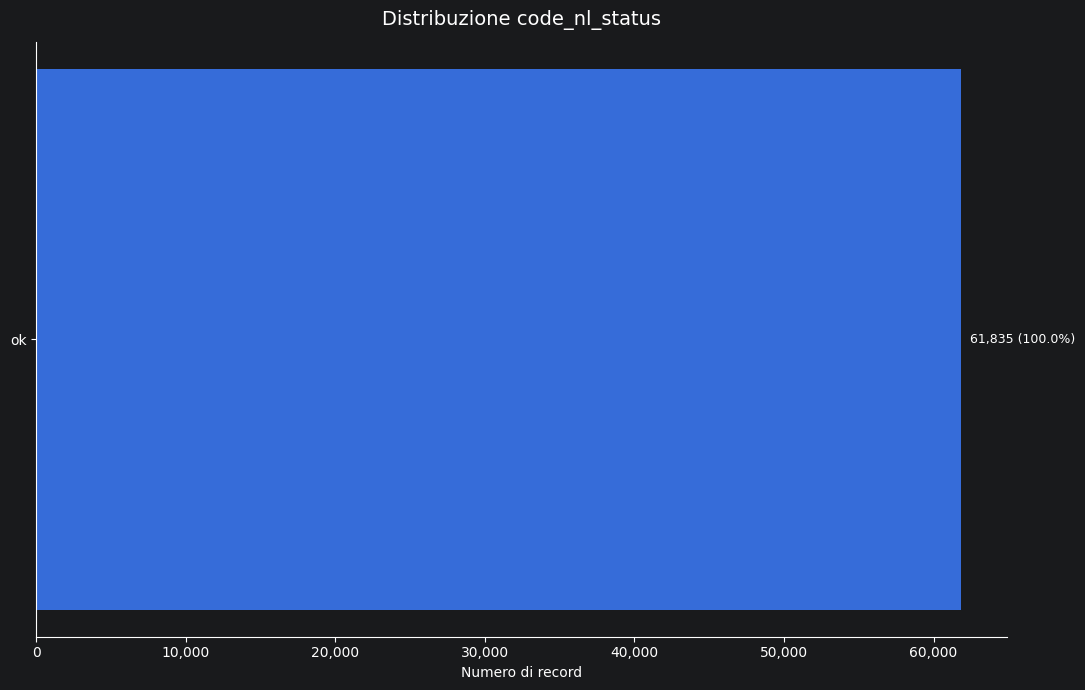

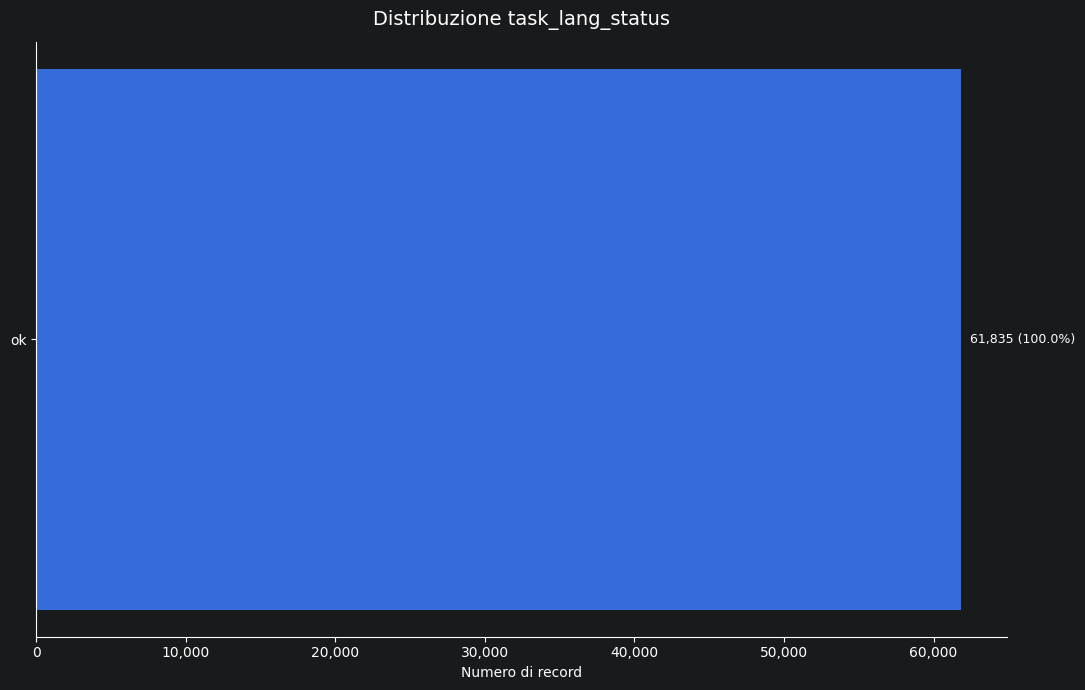

,metric,value
0,processed_ids,61835
1,final_ids,61835
2,processed_ids_missing_in_final,0
3,final_ids_missing_in_processed,0


In [13]:
if processed_df.empty:
    print("processed_df è vuoto: non posso eseguire i controlli sugli status.")
else:
    status_columns = [col for col in ["overall_status", "code_nl_status", "task_lang_status"] if col in processed_df.columns]
    status_summary = []

    for col in status_columns:
        counts = processed_df[col].fillna("MISSING").astype(str).value_counts()
        for status, count in counts.items():
            status_summary.append({"status_column": col, "status": status, "count": int(count), "percentage": count / len(processed_df)})

    status_summary_df = pd.DataFrame(status_summary)
    display(status_summary_df)
    save_table(status_summary_df, "status_summary")

    for col in status_columns:
        counts = processed_df[col].fillna("MISSING").astype(str).value_counts()
        plot_barh_counts(
            counts,
            title=f"Distribuzione {col}",
            xlabel="Numero di record",
            top_n=20,
            save_name=f"status_{col}.png",
        )

    if "conversation_id" in processed_df.columns and "conversation_id" in df.columns:
        processed_ids = set(processed_df["conversation_id"].dropna().astype(str))
        final_ids = set(df["conversation_id"].dropna().astype(str))
        join_check = pd.DataFrame({
            "metric": [
                "processed_ids",
                "final_ids",
                "processed_ids_missing_in_final",
                "final_ids_missing_in_processed",
            ],
            "value": [
                len(processed_ids),
                len(final_ids),
                len(processed_ids - final_ids),
                len(final_ids - processed_ids),
            ],
        })
        display(join_check)
        save_table(join_check, "processed_final_join_check")


In [14]:
if not processed_df.empty and "overall_status" in processed_df.columns:
    bad_df = processed_df.loc[processed_df["overall_status"].isin(["partial_error", "error"])].copy()
    print(f"Record con partial_error/error: {len(bad_df):,}")

    if not bad_df.empty:
        bad_error_counts = bad_df["overall_error"].fillna("MISSING").astype(str).value_counts().head(30)
        display(bad_error_counts.rename_axis("overall_error").reset_index(name="count"))
        plot_barh_counts(
            bad_error_counts,
            title="Errori più frequenti nei record problematici",
            xlabel="Numero di record",
            top_n=20,
            figsize=(12, 8),
            save_name="top_processing_errors.png",
        )


Record con partial_error/error: 0


## 5. Distribuzione Predicted Language

Analizzo la distribuzione di `detected_language`, cioè la lingua predetta dal classificatore LLM dopo la separazione Code/NL.


,detected_language,count,percentage
0,EN,42148,0.681620
1,RU,7214,0.116665
2,FR,4652,0.075232
3,UNKNOWN,2993,0.048403
4,ZH,1408,0.022770
5,ES,583,0.009428
6,PT,529,0.008555
7,AR,500,0.008086
8,FA,316,0.005110
9,IT,281,0.004544


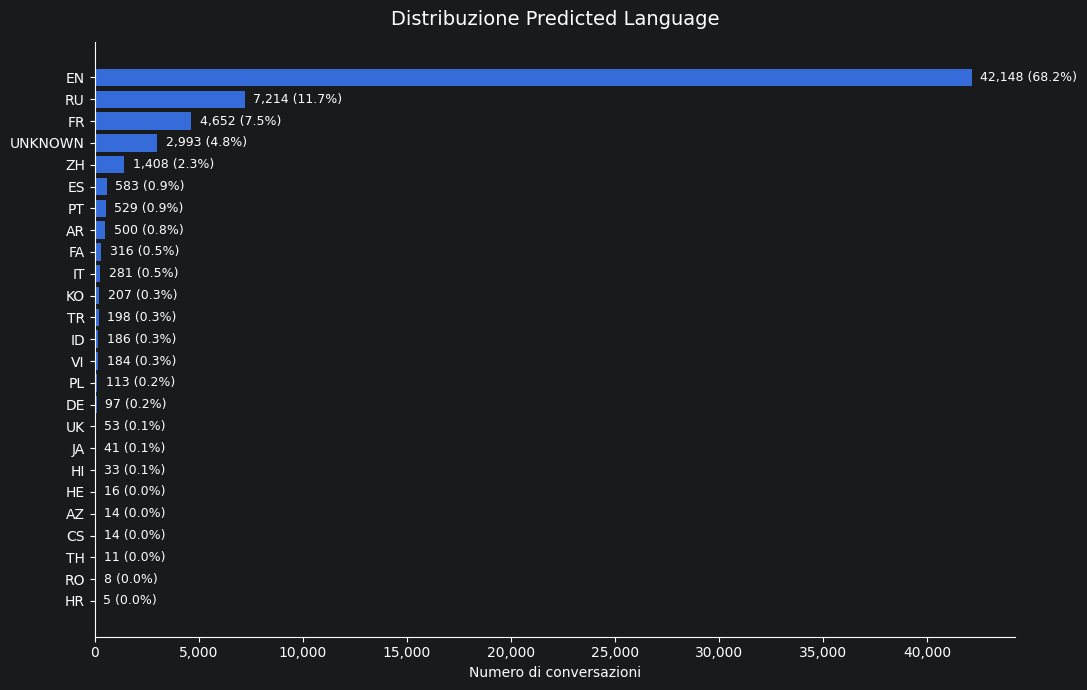

,value,count,percentage
0,EN,42148,0.681962
1,RU,7214,0.116724
2,FR,4652,0.075270
3,UNKNOWN,2993,0.048427
4,ZH,1408,0.022782
5,ES,583,0.009433
6,PT,529,0.008559
7,AR,500,0.008090
8,FA,316,0.005113
9,IT,281,0.004547


In [15]:
language_counts = df["detected_language"].fillna("MISSING").astype(str).value_counts()
language_distribution = language_counts.rename_axis("detected_language").reset_index(name="count")
language_distribution["percentage"] = language_distribution["count"] / max(len(df), 1)

display(language_distribution.head(50))
save_table(language_distribution, "detected_language_distribution")

plot_barh_counts(
    language_counts,
    title="Distribuzione Predicted Language",
    xlabel="Numero di conversazioni",
    top_n=TOP_N,
    save_name="predicted_language_distribution.png",
)


## 6. Distribuzione Task

Analizzo la distribuzione di `task_category`, cioè la categoria del task predetta dal classificatore LLM.


,task_category,count,percentage
0,CODE_GENERATION,18478,0.298828
1,EXPLANATION,12334,0.199466
2,CODE_MODIFICATION,10091,0.163192
3,BUG_FIXING,9133,0.147700
4,AMBIGUOUS,5021,0.081200
5,OTHER,3303,0.053416
6,REFACTORING,2063,0.033363
7,DATA_QUERY,1412,0.022835


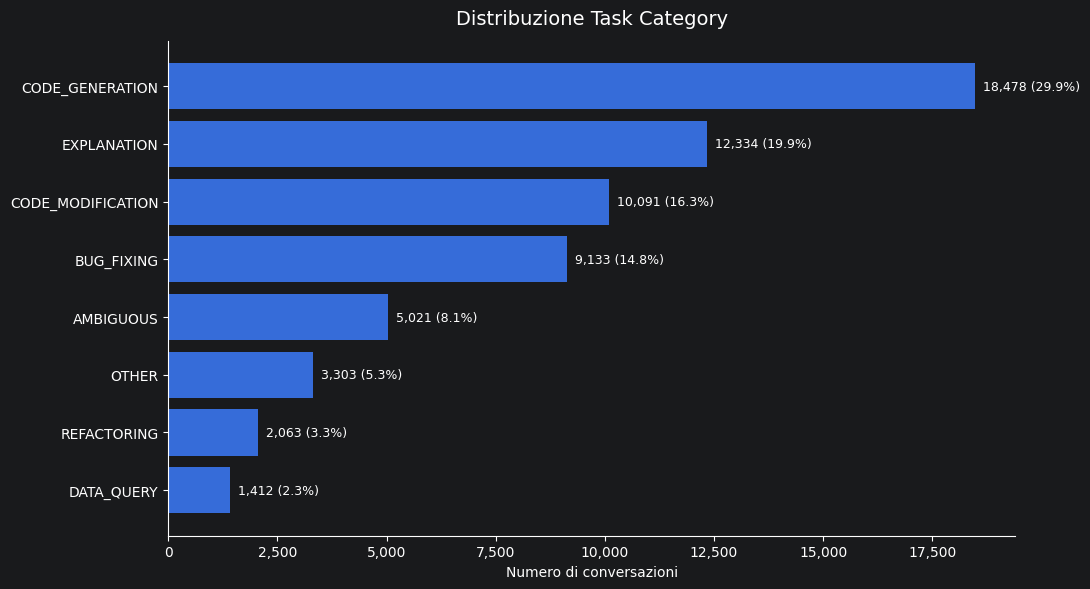

,value,count,percentage
0,CODE_GENERATION,18478,0.298828
1,EXPLANATION,12334,0.199466
2,CODE_MODIFICATION,10091,0.163192
3,BUG_FIXING,9133,0.147700
4,AMBIGUOUS,5021,0.081200
5,OTHER,3303,0.053416
6,REFACTORING,2063,0.033363
7,DATA_QUERY,1412,0.022835


In [16]:
task_counts = df["task_category"].fillna("MISSING").astype(str).value_counts()
task_distribution = task_counts.rename_axis("task_category").reset_index(name="count")
task_distribution["percentage"] = task_distribution["count"] / max(len(df), 1)

display(task_distribution)
save_table(task_distribution, "task_category_distribution")

plot_barh_counts(
    task_counts,
    title="Distribuzione Task Category",
    xlabel="Numero di conversazioni",
    top_n=30,
    figsize=(11, 6),
    save_name="task_category_distribution.png",
)


detected_language,AR,AZ,BE,BG,BN,BS,CA,CS,DA,DE,EL,EN,ES,FA,FI,FR,HE,HI,HR,HU,ID,IT,JA,KA,KO,MG,MY,NL,PL,PT,RO,RU,SK,SV,SW,TH,TR,UK,UNKNOWN,UR,VI,ZH
task_category,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AMBIGUOUS,17,1,0,0,0,0,0,1,0,3,0,1541,20,11,0,17,1,1,0,1,8,17,0,0,5,0,0,0,1,9,1,312,0,0,0,1,5,5,2993,0,2,48
BUG_FIXING,74,1,0,0,0,0,0,2,0,29,2,4454,133,68,0,2007,3,3,0,0,32,71,12,0,33,0,0,0,32,125,1,1690,0,0,0,1,50,8,0,0,13,289
CODE_GENERATION,176,6,0,0,0,0,0,4,1,16,1,14959,69,32,0,2108,0,6,1,0,18,31,1,0,16,0,0,0,10,52,2,744,2,0,1,1,20,7,0,1,24,169
CODE_MODIFICATION,114,1,0,1,0,0,2,5,0,22,2,6442,141,116,2,200,5,4,3,0,68,56,7,2,89,0,0,1,41,140,4,2194,0,0,0,0,74,17,0,0,19,319
DATA_QUERY,6,0,0,0,0,0,0,1,0,4,0,1172,8,2,0,22,1,9,0,0,2,2,3,0,1,0,0,0,1,4,0,124,0,1,0,0,0,3,0,0,0,46
EXPLANATION,82,5,0,0,1,0,0,1,0,10,0,10015,66,39,0,230,1,10,0,1,13,56,14,0,39,1,1,1,13,81,0,1153,0,1,1,4,28,8,0,1,101,357
OTHER,21,0,1,0,0,0,0,0,0,4,0,2409,46,39,0,57,4,0,1,0,9,17,4,0,15,0,0,1,7,29,0,494,0,0,0,4,11,2,0,0,18,110
REFACTORING,10,0,0,0,0,1,0,0,0,9,0,1156,100,9,0,11,1,0,0,0,36,31,0,0,9,0,0,0,8,89,0,503,0,0,0,0,10,3,0,0,7,70


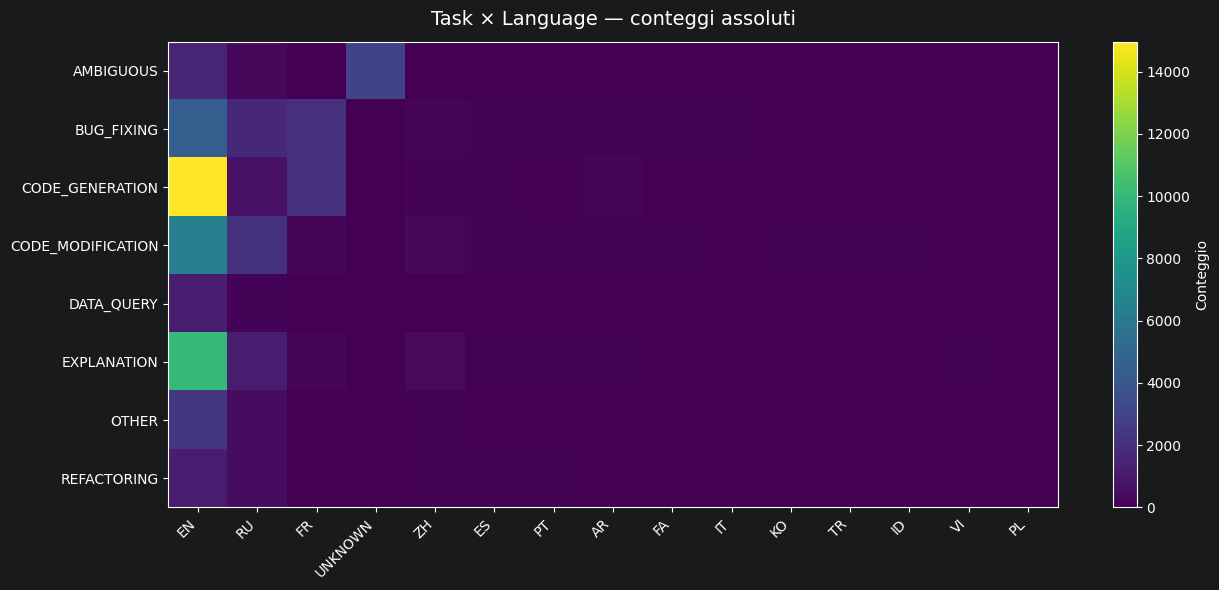

In [17]:
# Vista incrociata lingua-task per una prima ispezione globale.
task_language_crosstab = pd.crosstab(
    df["task_category"].fillna("MISSING"),
    df["detected_language"].fillna("MISSING"),
)

display(task_language_crosstab)
save_table(task_language_crosstab.reset_index(), "task_language_crosstab")

# Heatmap semplice con matplotlib sui linguaggi più frequenti.
top_languages_for_heatmap = language_counts.head(15).index.tolist()
heatmap_df = task_language_crosstab.reindex(columns=top_languages_for_heatmap, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(heatmap_df.values, aspect="auto")
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_df.index)
ax.set_title("Task × Language — conteggi assoluti", fontsize=14, pad=12)
fig.colorbar(im, ax=ax, label="Conteggio")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "task_language_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()


## 7. Distribuzione Language per Task Ambiguous

Verifico in quali lingue sono concentrati i record classificati come `AMBIGUOUS`.


Record AMBIGUOUS: 5,021 (8.12%)


,detected_language,count,percentage_within_ambiguous
0,UNKNOWN,2993,0.596096
1,EN,1541,0.306911
2,RU,312,0.062139
3,ZH,48,0.009560
4,ES,20,0.003983
5,FR,17,0.003386
6,IT,17,0.003386
7,AR,17,0.003386
8,FA,11,0.002191
9,PT,9,0.001792


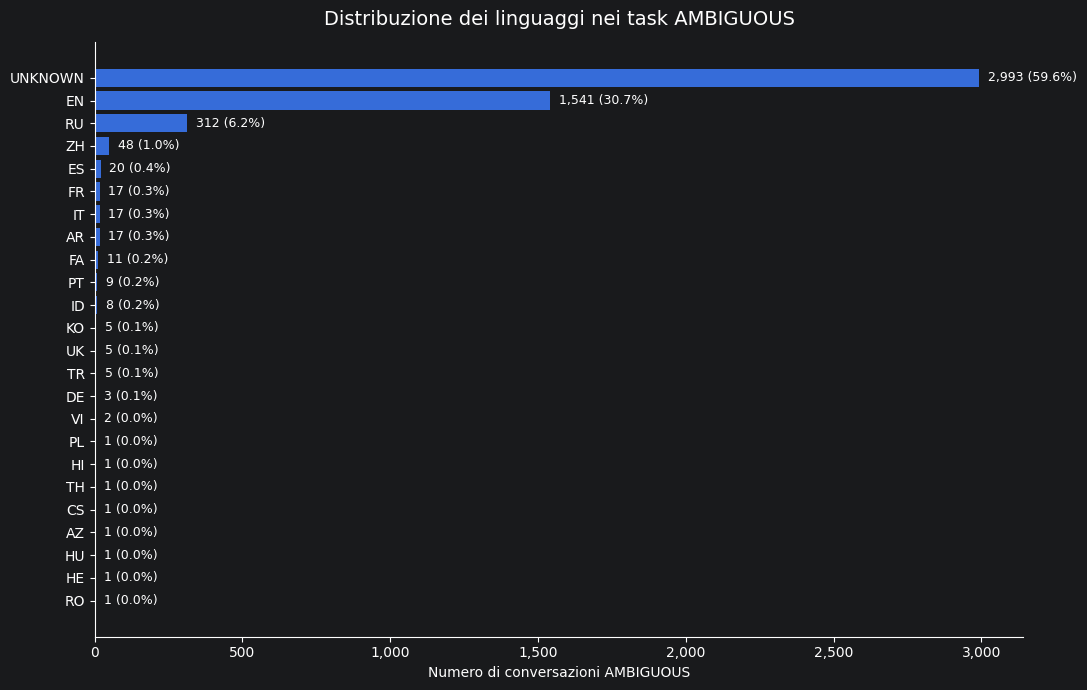

In [18]:
ambiguous_df = df.loc[df["task_category"].fillna("").astype(str).str.upper() == "AMBIGUOUS"].copy()
print(f"Record AMBIGUOUS: {len(ambiguous_df):,} ({len(ambiguous_df) / max(len(df), 1):.2%})")

if ambiguous_df.empty:
    print("Nessun record AMBIGUOUS trovato.")
else:
    ambiguous_language_counts = ambiguous_df["detected_language"].fillna("MISSING").astype(str).value_counts()
    ambiguous_language_distribution = ambiguous_language_counts.rename_axis("detected_language").reset_index(name="count")
    ambiguous_language_distribution["percentage_within_ambiguous"] = ambiguous_language_distribution["count"] / len(ambiguous_df)
    display(ambiguous_language_distribution.head(50))
    save_table(ambiguous_language_distribution, "ambiguous_language_distribution")

    plot_barh_counts(
        ambiguous_language_counts,
        title="Distribuzione dei linguaggi nei task AMBIGUOUS",
        xlabel="Numero di conversazioni AMBIGUOUS",
        top_n=TOP_N,
        save_name="ambiguous_language_distribution.png",
    )


## 8. Distribuzione dei Task per Linguaggio EN

Filtro i record con `detected_language == EN` e analizzo la distribuzione dei task dentro questo sottoinsieme.


Record EN: 42,148 (68.16%)


,task_category,count,percentage_within_en
0,CODE_GENERATION,14959,0.354916
1,EXPLANATION,10015,0.237615
2,CODE_MODIFICATION,6442,0.152842
3,BUG_FIXING,4454,0.105675
4,OTHER,2409,0.057156
5,AMBIGUOUS,1541,0.036562
6,DATA_QUERY,1172,0.027807
7,REFACTORING,1156,0.027427


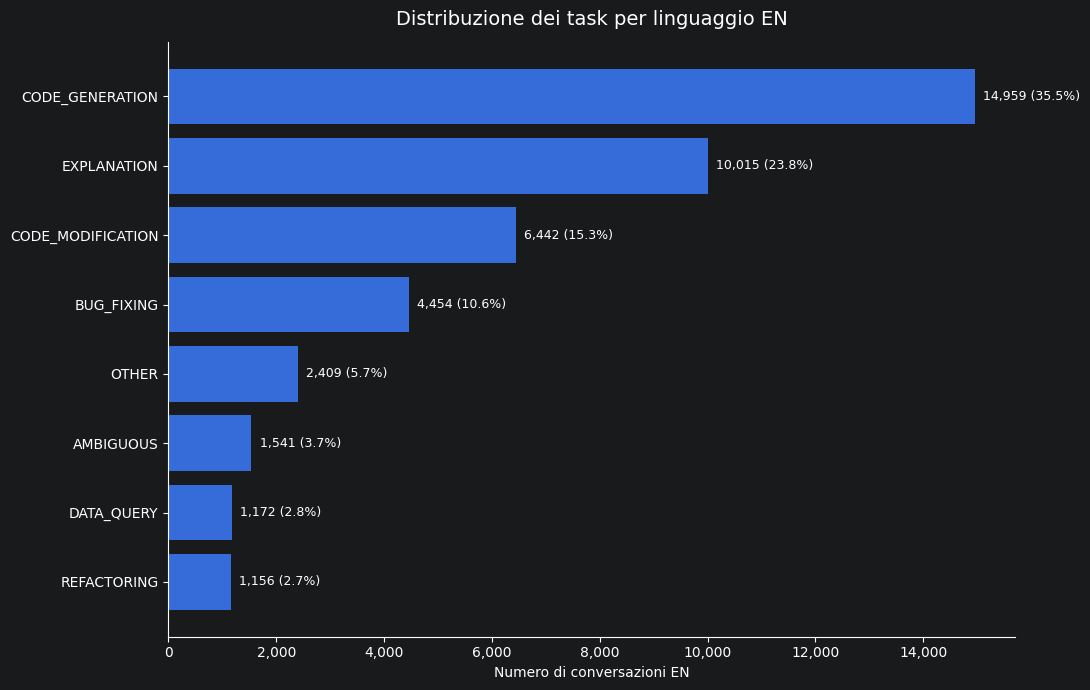

In [19]:
en_df = df.loc[df["detected_language"].fillna("").astype(str).str.upper() == "EN"].copy()
print(f"Record EN: {len(en_df):,} ({len(en_df) / max(len(df), 1):.2%})")

if en_df.empty:
    print("Nessun record EN trovato.")
else:
    en_task_counts = en_df["task_category"].fillna("MISSING").astype(str).value_counts()
    en_task_distribution = en_task_counts.rename_axis("task_category").reset_index(name="count")
    en_task_distribution["percentage_within_en"] = en_task_distribution["count"] / len(en_df)
    display(en_task_distribution)
    save_table(en_task_distribution, "en_task_distribution")

    plot_barh_counts(
        en_task_counts,
        title="Distribuzione dei task per linguaggio EN",
        xlabel="Numero di conversazioni EN",
        top_n=30,
        save_name="en_task_distribution.png",
    )


## 9. Analisi Linguaggi di Programmazione

Questa analisi considera solo:

- conversazioni con `detected_language == EN`;
- esclusione dei task `AMBIGUOUS`, `EXPLANATION`, `OTHER`, `DATA_QUERY`;
- solo risposte dell'assistente, non prompt utente;
- blocchi di codice delimitati da triple backticks.

Per ogni blocco:

1. conto il blocco;
2. provo a leggere il linguaggio dichiarato subito dopo i triple backticks;
3. se non è presente, lo classifico inizialmente come `UNKNOWN`;
4. provo a inferirlo usando `guesslang` se disponibile, poi `pygments`, poi alcune euristiche leggere.


In [20]:
EXCLUDED_TASKS_FOR_PL_ANALYSIS = {"AMBIGUOUS", "EXPLANATION", "OTHER", "DATA_QUERY"}

pl_base_df = df.loc[
    (df["detected_language"].fillna("").astype(str).str.upper() == "EN")
    & (~df["task_category"].fillna("").astype(str).str.upper().isin(EXCLUDED_TASKS_FOR_PL_ANALYSIS))
].copy()

print(f"Record candidati per analisi linguaggi di programmazione: {len(pl_base_df):,}")
display(pl_base_df["task_category"].value_counts().rename_axis("task_category").reset_index(name="count"))


Record candidati per analisi linguaggi di programmazione: 27,011


,task_category,count
0,CODE_GENERATION,14959
1,CODE_MODIFICATION,6442
2,BUG_FIXING,4454
3,REFACTORING,1156


In [21]:
CODE_FENCE_RE = re.compile(
    r"```[ \t]*([^\n\r`]*)[\r\n](.*?)```",
    flags=re.DOTALL,
)

LANGUAGE_ALIASES = {
    "py": "python",
    "python3": "python",
    "js": "javascript",
    "jsx": "javascript",
    "mjs": "javascript",
    "cjs": "javascript",
    "ts": "typescript",
    "tsx": "typescript",
    "sh": "shell",
    "bash": "shell",
    "zsh": "shell",
    "shellscript": "shell",
    "console": "shell",
    "cmd": "batch",
    "bat": "batch",
    "ps1": "powershell",
    "pwsh": "powershell",
    "yml": "yaml",
    "html5": "html",
    "css3": "css",
    "md": "markdown",
    "c++": "cpp",
    "cpp": "cpp",
    "cxx": "cpp",
    "cc": "cpp",
    "c#": "csharp",
    "cs": "csharp",
    "f#": "fsharp",
    "fs": "fsharp",
    "golang": "go",
    "rb": "ruby",
    "kt": "kotlin",
    "rs": "rust",
    "pl": "perl",
    "rscript": "r",
    "objective-c": "objective-c",
    "objc": "objective-c",
    "text": "unknown",
    "plain": "unknown",
    "plaintext": "unknown",
    "plain text": "unknown",
    "": "unknown",
}

PYGMENTS_NAME_ALIASES = {
    "python": "python",
    "javascript": "javascript",
    "typescript": "typescript",
    "java": "java",
    "c": "c",
    "c++": "cpp",
    "c#": "csharp",
    "php": "php",
    "html": "html",
    "css": "css",
    "sql": "sql",
    "bash": "shell",
    "shell": "shell",
    "json": "json",
    "yaml": "yaml",
    "xml": "xml",
    "ruby": "ruby",
    "go": "go",
    "rust": "rust",
    "swift": "swift",
    "kotlin": "kotlin",
    "scala": "scala",
    "r": "r",
    "matlab": "matlab",
    "powershell": "powershell",
}


def normalize_language_name(raw: Any) -> str:
    if raw is None:
        return "unknown"

    text = str(raw).strip().lower()
    if not text:
        return "unknown"

    # Alcune fence sono del tipo: ```python title="..." oppure ```{r}
    text = text.strip("{}[]()")
    first_token = re.split(r"\s+", text)[0].strip().strip("{}[](),;:")
    first_token = first_token.replace(".", "") if first_token.startswith(".") else first_token

    return LANGUAGE_ALIASES.get(first_token, first_token or "unknown")


def extract_code_blocks_from_text(text: str) -> list[dict[str, Any]]:
    blocks = []
    if not isinstance(text, str) or not text:
        return blocks

    for match_idx, match in enumerate(CODE_FENCE_RE.finditer(text), start=1):
        raw_language = match.group(1).strip()
        code = match.group(2)
        fence_language = normalize_language_name(raw_language)
        blocks.append({
            "block_index": match_idx,
            "fence_language_raw": raw_language,
            "fence_language": fence_language,
            "code": code,
        })

    return blocks


def heuristic_guess_language(code: str) -> str:
    text = code.strip()
    lower = text.lower()

    if not text:
        return "unknown"

    if re.match(r"^\s*[{\[]", text):
        try:
            json.loads(text)
            return "json"
        except Exception:
            pass

    if re.search(r"<\/?(html|body|div|span|script|style|template|head|p|a|ul|li)\b", lower):
        return "html"
    if re.search(r"\b(select|insert|update|delete|create table|alter table|from|where|join)\b", lower) and ";" in text:
        return "sql"
    if re.search(r"^\s*(sudo |pip |npm |yarn |pnpm |cd |mkdir |rm |cp |mv |git |docker |kubectl |curl |wget )", lower, flags=re.MULTILINE):
        return "shell"
    if re.search(r"\b(def |import |from |print\(|self\.|if __name__ == ['\"]__main__['\"])", text):
        return "python"
    if re.search(r"\b(const |let |var |function |console\.log|=>|require\(|module\.exports|export default)\b", text):
        return "javascript"
    if re.search(r"\b(interface |type \w+\s*=|implements |readonly |public |private )", text) and re.search(r":\s*\w+", text):
        return "typescript"
    if re.search(r"\b(public class|public static void main|System\.out\.println|import java\.)\b", text):
        return "java"
    if re.search(r"#include\s*<|std::|cout\s*<<|cin\s*>>", text):
        return "cpp"
    if re.search(r"using System;|Console\.WriteLine|namespace \w+", text):
        return "csharp"
    if "<?php" in lower or re.search(r"\$\w+\s*=", text):
        return "php"
    if re.search(r"\bpackage main\b|\bfunc main\(|fmt\.Print", text):
        return "go"
    if re.search(r"\bfn main\(|println!\(|let mut\b", text):
        return "rust"
    if re.search(r"\b(class |def |puts |end\b)", text) and re.search(r"@[\w_]+|\.each do", text):
        return "ruby"
    if re.search(r"^[\w.-]+:\s*.+$", text, flags=re.MULTILINE) and not re.search(r"[{};]", text):
        return "yaml"

    return "unknown"


def guess_unknown_language(code: str) -> tuple[str, str]:
    """Ritorna (language, source)."""
    if GUESSLANG_AVAILABLE and GUESSLANG_MODEL is not None:
        try:
            guessed = GUESSLANG_MODEL.language_name(code)
            norm = normalize_language_name(guessed)
            if norm != "unknown":
                return norm, "guesslang"
        except Exception:
            pass

    if PYGMENTS_AVAILABLE:
        try:
            lexer = guess_lexer(code)
            norm = normalize_language_name(PYGMENTS_NAME_ALIASES.get(lexer.name.lower(), lexer.name.lower()))
            if norm != "unknown":
                return norm, "pygments"
        except Exception:
            pass

    heuristic = heuristic_guess_language(code)
    if heuristic != "unknown":
        return heuristic, "heuristic"

    return "unknown", "unknown"


In [22]:
code_block_rows = []

for row in tqdm(pl_base_df.itertuples(index=False), total=len(pl_base_df), desc="Extracting assistant code blocks"):
    conversation_id = getattr(row, "conversation_id")
    task_category = getattr(row, "task_category")
    detected_language = getattr(row, "detected_language")
    assistants = get_messages_by_role(getattr(row, "conversation"), "assistant")

    for assistant_idx, message in enumerate(assistants, start=1):
        content = str(message.get("content", ""))
        blocks = extract_code_blocks_from_text(content)

        for block in blocks:
            fence_language = block["fence_language"]
            code = block["code"]

            if fence_language == "unknown":
                final_language, language_source = guess_unknown_language(code)
            else:
                final_language, language_source = fence_language, "fence"

            code_block_rows.append({
                "conversation_id": conversation_id,
                "task_category": task_category,
                "detected_language": detected_language,
                "assistant_message_index": assistant_idx,
                "block_index": block["block_index"],
                "fence_language_raw": block["fence_language_raw"],
                "fence_language": fence_language,
                "programming_language": final_language,
                "language_source": language_source,
                "code": code,
                "code_char_len": len(code),
                "code_line_count": len(code.splitlines()),
            })

code_blocks_df = pd.DataFrame(code_block_rows)
print(f"Blocchi di codice estratti dalle risposte LLM: {len(code_blocks_df):,}")

if not code_blocks_df.empty:
    display(code_blocks_df.head(10))
    code_blocks_df.drop(columns=["code"]).to_csv(TABLES_DIR / "assistant_code_blocks_metadata.csv", index=False)
else:
    print("Nessun code block delimitato da triple backticks trovato nel sottoinsieme selezionato.")


Extracting assistant code blocks: 100%|██████████| 27011/27011 [00:10<00:00, 2546.64it/s]


Blocchi di codice estratti dalle risposte LLM: 88,039


,conversation_id,task_category,detected_language,assistant_message_index,block_index,fence_language_raw,fence_language,programming_language,language_source,code,code_char_len,code_line_count
0,84b76971d297c9d3b33edc6e6380ab4f,CODE_GENERATION,EN,1,1,python,python,python,fence,import bpy\nimport math\n\ndef align_objects(distance):\n \n # Get a list of selected objects in the scene\n objects = [obj for obj in bpy.context.selected_objects]\n\...,745,27
1,bcdc32b84c55fbc6ed31b1432f36c8e4,BUG_FIXING,EN,1,1,css,css,css,fence,.language-option {\n position: fixed;\n display: none;\n justify-content: center;\n align-items: center;\n padding-top: 64px;\n width: 100%;\n height: 100%;\n backgroun...,186,10
2,01258be3f4c54a12ad8d1f0328ab4068,BUG_FIXING,EN,1,1,java,java,java,fence,import java.awt.event.WindowAdapter;\nimport java.awt.event.WindowEvent;\n,72,2
3,f037e5089daf75a37f3c1c36ad8819d7,CODE_MODIFICATION,EN,1,1,,unknown,python,pygments,import { subDays } from 'date-fns';\n,36,1
4,f037e5089daf75a37f3c1c36ad8819d7,CODE_MODIFICATION,EN,1,2,,unknown,unknown,unknown,"endDate: {\n gte: subDays(new Date(), 5),\n lte: new Date()\n},\n",63,4
5,f037e5089daf75a37f3c1c36ad8819d7,CODE_MODIFICATION,EN,1,3,,unknown,gdscript,pygments,"const [questionnaire, categories] = await prisma.$transaction([\n prisma.questionnaire.findFirst({\n orderBy: [{ startDate: 'desc' }],\n where: {\n ...filter,\n ...",1317,60
6,8b0250db0a8f524132011c6bd3dbb1d2,BUG_FIXING,EN,1,1,,unknown,python,pygments,import math\nimport time\nimport curses\n\ndef main(stdscr):\n stdscr.clear()\n stdscr.nodelay(1) # Enable non-blocking input\n curses.curs_set(0) # Hide the cursor\...,2697,81
7,ce225613c3240db229bcc8f37f8fc85c,CODE_GENERATION,EN,1,1,python,python,python,fence,"from pyspark.sql.functions import udf\nfrom pyspark.sql.types import StringType\n\ndef remove_first_element(str_col):\n """"""\n Removes the first element of a string column...",574,16
8,ce225613c3240db229bcc8f37f8fc85c,CODE_GENERATION,EN,1,2,python,python,python,fence,"from pyspark.sql.functions import col\n\n# create a dataframe with a string column\ndata = [(""John Smith"",), (""Jane Doe"",), (""Bob Johnson"",)]\ndf = spark.createDataFrame(data, ...",350,11
9,ce225613c3240db229bcc8f37f8fc85c,CODE_GENERATION,EN,1,3,,unknown,scdoc,pygments,+--------+\n|new_name|\n+--------+\n| Smith |\n| Doe |\n|Johnson |\n+--------+\n,77,7


,metric,value
0,eligible_records,27011.000000
1,records_with_at_least_one_code_block,27001.000000
2,total_code_blocks,88039.000000
3,avg_blocks_per_eligible_record,3.259376
4,avg_blocks_per_record_with_blocks,3.260583
5,blocks_with_fence_language,79329.000000
6,blocks_without_fence_language,8710.000000
7,blocks_still_unknown_after_inference,2643.000000


,programming_language,count,percentage
0,python,23985,0.272436
1,shell,12599,0.143107
2,javascript,9875,0.112166
3,html,4304,0.048887
4,json,3222,0.036597
5,cpp,2749,0.031225
6,unknown,2643,0.030021
7,java,2375,0.026977
8,csharp,2245,0.025500
9,typescript,1849,0.021002


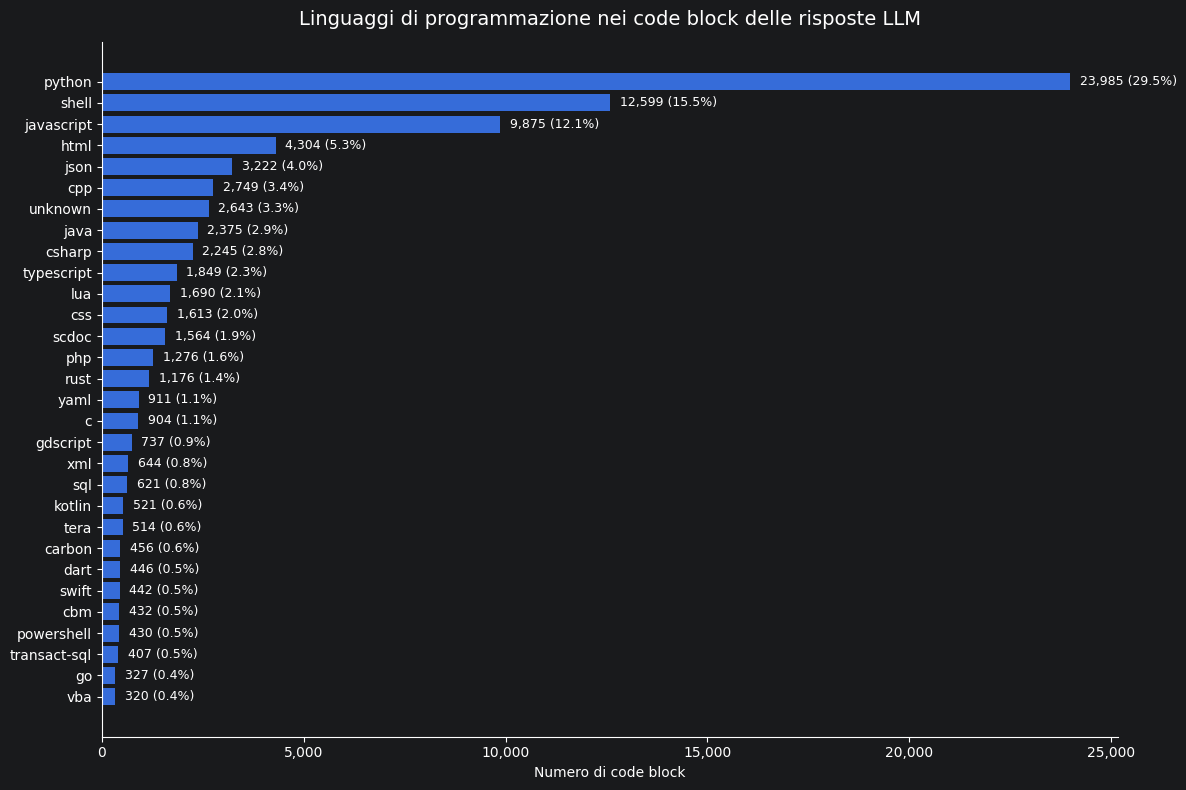

In [23]:
if code_blocks_df.empty:
    print("Nessun dato da visualizzare.")
else:
    block_summary = pd.DataFrame({
        "metric": [
            "eligible_records",
            "records_with_at_least_one_code_block",
            "total_code_blocks",
            "avg_blocks_per_eligible_record",
            "avg_blocks_per_record_with_blocks",
            "blocks_with_fence_language",
            "blocks_without_fence_language",
            "blocks_still_unknown_after_inference",
        ],
        "value": [
            len(pl_base_df),
            code_blocks_df["conversation_id"].nunique(),
            len(code_blocks_df),
            len(code_blocks_df) / max(len(pl_base_df), 1),
            len(code_blocks_df) / max(code_blocks_df["conversation_id"].nunique(), 1),
            int((code_blocks_df["language_source"] == "fence").sum()),
            int((code_blocks_df["fence_language"] == "unknown").sum()),
            int((code_blocks_df["programming_language"] == "unknown").sum()),
        ],
    })

    display(block_summary)
    save_table(block_summary, "programming_language_block_summary")

    lang_counts = code_blocks_df["programming_language"].fillna("unknown").astype(str).value_counts()
    lang_distribution = lang_counts.rename_axis("programming_language").reset_index(name="count")
    lang_distribution["percentage"] = lang_distribution["count"] / len(code_blocks_df)
    display(lang_distribution.head(50))
    save_table(lang_distribution, "programming_language_distribution")

    plot_barh_counts(
        lang_counts,
        title="Linguaggi di programmazione nei code block delle risposte LLM",
        xlabel="Numero di code block",
        top_n=30,
        figsize=(12, 8),
        save_name="programming_language_distribution.png",
    )


,language_source,count,percentage
0,fence,79329,0.901067
1,pygments,5215,0.059235
2,unknown,2643,0.030021
3,heuristic,852,0.009678


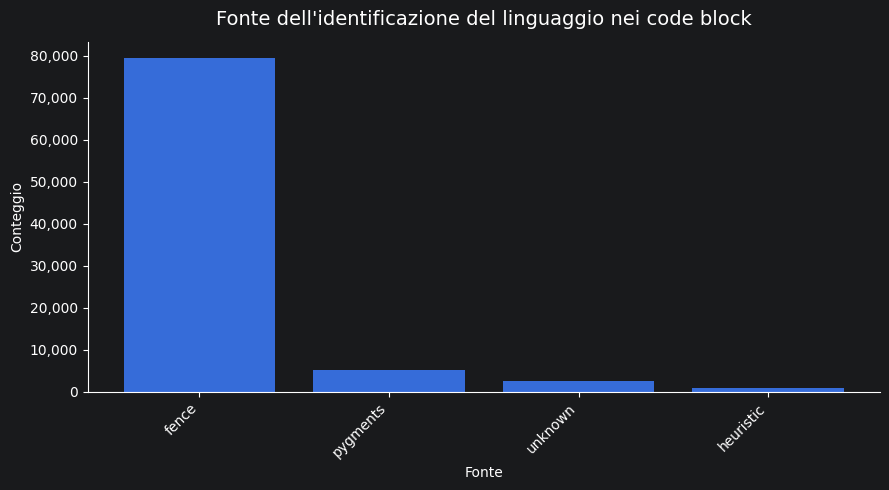

programming_language,"""",""")[0].split("";"")[0].strip",""".",$',',-,/,/g,<html>,<x,@@@,"\\w+)"">>","\n""","\n\n""",abap,abc,afl,aftereffects,ahk,al,antlr,apache,apex,applescript,arduino,are,as,asm,asoundrc,asp.net,aspx,assembly,astro,autohotkey,autoit,basic,batch,batchfile,bbc,bds,bdscript,begin,bg.js,bibtex,blade,blocks,blocks.,blueprint,bms,bnf,bp,brainfuck,bugs,c,cabal,caddyfile,carbon,cbm,cfg,chinese,...,sql,srt,ssml,stata,structured-text,structuredtext,svelte,svg,swift,swig,systemd,systemverilog,tablegen,tasm,tcl,tera,terminal,terraform,tex,three,tlis,tmsh,tmux,toml,transact-sql,troff,twig,txt,typescript,typescript:src/utils/culturecockpitmock.ts,unknown,vb,vb.net,vba,vbnet,vbscript,verilog,verse,vhdl,vim,vtl,vtt,vue,wgsl,wolfram,world,x++,xaml,xhtml,xml,xml+django/jinja,xml+php,xml+ruby,xpath,xslt,yaml,yara,yul,zig,"~s~s"""
task_category,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
BUG_FIXING,20,1,0,0,9,0,5,9,0,0,0,0,0,0,0,0,0,0,6,0,0,3,1,2,0,0,0,3,0,0,0,36,4,10,0,4,91,0,0,0,0,0,0,4,0,0,0,1,0,0,0,0,0,156,0,0,89,62,0,0,...,155,0,0,1,0,0,4,1,114,0,0,1,0,1,0,72,0,0,0,0,0,3,1,11,67,0,0,0,481,1,362,120,44,66,0,0,15,0,1,12,0,0,14,4,0,5,4,1,0,115,1,0,3,0,0,272,0,0,0,0
CODE_GENERATION,2,0,1,1,7,0,2,2,0,1,1,0,0,0,22,9,1,1,12,9,3,11,1,5,5,0,0,11,0,1,1,34,3,13,1,24,87,1,1,1,1,1,0,3,10,6,0,6,1,1,1,64,4,451,0,2,290,316,2,2,...,299,1,1,0,3,1,28,76,173,3,2,22,0,2,6,373,4,0,2,0,2,0,0,129,275,1,3,23,647,0,1860,58,7,178,4,2,50,0,1,2,2,2,38,5,1,23,3,3,1,338,2,8,0,0,0,485,0,0,1,0
CODE_MODIFICATION,27,0,0,0,18,1,2,2,1,0,0,1,4,7,16,1,0,0,6,0,0,21,0,0,0,1,1,2,0,0,0,23,1,16,0,1,83,0,0,0,0,0,1,2,2,0,1,0,0,2,0,8,0,249,2,0,72,48,0,0,...,158,0,0,0,0,0,22,5,150,0,0,2,1,2,0,60,0,2,0,1,0,0,0,43,60,0,0,4,613,0,382,63,30,68,8,0,12,6,0,6,0,1,54,0,0,6,0,0,0,186,4,0,0,3,1,138,0,1,3,1
REFACTORING,9,0,0,0,5,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,16,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,0,48,0,0,5,6,0,0,...,9,0,0,0,0,0,0,0,5,0,0,0,0,1,0,9,0,0,0,0,0,0,0,9,5,0,0,2,108,0,39,2,0,8,0,0,8,0,0,1,0,0,2,0,0,0,1,0,0,5,0,0,0,0,0,16,1,0,0,0


In [24]:
if not code_blocks_df.empty:
    source_counts = code_blocks_df["language_source"].fillna("unknown").astype(str).value_counts()
    source_distribution = source_counts.rename_axis("language_source").reset_index(name="count")
    source_distribution["percentage"] = source_distribution["count"] / len(code_blocks_df)
    display(source_distribution)
    save_table(source_distribution, "programming_language_source_distribution")

    plot_vertical_counts(
        source_counts,
        title="Fonte dell'identificazione del linguaggio nei code block",
        xlabel="Fonte",
        top_n=10,
        figsize=(9, 5),
        save_name="programming_language_source_distribution.png",
    )

    task_lang_blocks = pd.crosstab(
        code_blocks_df["task_category"].fillna("MISSING"),
        code_blocks_df["programming_language"].fillna("unknown"),
    )
    display(task_lang_blocks)
    save_table(task_lang_blocks.reset_index(), "task_programming_language_crosstab")


,code_blocks_per_conversation,conversation_count
0,1,13828
1,2,3499
2,3,2423
3,4,1484
4,5,1161
5,6,934
6,7,694
7,8,615
8,9,452
9,10,394


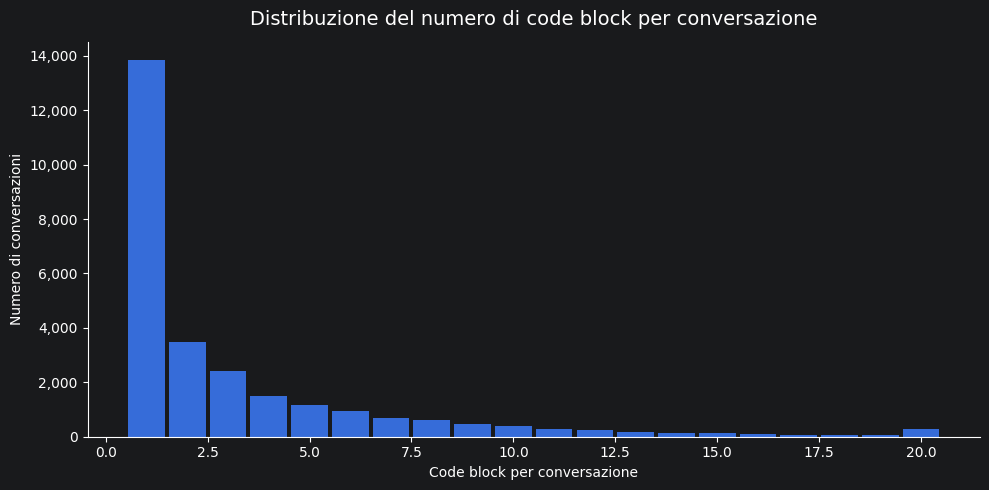

In [25]:
if not code_blocks_df.empty:
    blocks_per_conversation = code_blocks_df.groupby("conversation_id").size().rename("code_block_count")
    block_count_distribution = blocks_per_conversation.value_counts().sort_index()

    display(block_count_distribution.rename_axis("code_blocks_per_conversation").reset_index(name="conversation_count"))
    save_table(block_count_distribution.rename_axis("code_blocks_per_conversation").reset_index(name="conversation_count"), "code_blocks_per_conversation_distribution")

    fig, ax = plt.subplots(figsize=(10, 5))
    clipped = blocks_per_conversation.clip(upper=blocks_per_conversation.quantile(.99))
    bins = np.arange(0.5, clipped.max() + 1.5, 1)
    ax.hist(clipped, bins=bins, rwidth=0.9)
    ax.set_title("Distribuzione del numero di code block per conversazione", fontsize=14, pad=12)
    ax.set_xlabel("Code block per conversazione")
    ax.set_ylabel("Numero di conversazioni")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "code_blocks_per_conversation.png", dpi=220, bbox_inches="tight")
    plt.show()


In [26]:
# Esempi controllati di blocchi rimasti UNKNOWN dopo tutti i tentativi di inferenza.
if not code_blocks_df.empty:
    unknown_blocks = code_blocks_df.loc[code_blocks_df["programming_language"] == "unknown"].copy()
    print(f"Blocchi UNKNOWN dopo inferenza: {len(unknown_blocks):,}")

    if not unknown_blocks.empty:
        unknown_examples = unknown_blocks[[
            "conversation_id",
            "task_category",
            "fence_language_raw",
            "code_line_count",
            "code_char_len",
            "code",
        ]].head(10)
        display(unknown_examples)
        unknown_examples.to_csv(TABLES_DIR / "unknown_code_block_examples.csv", index=False)


Blocchi UNKNOWN dopo inferenza: 2,643


,conversation_id,task_category,fence_language_raw,code_line_count,code_char_len,code
4,f037e5089daf75a37f3c1c36ad8819d7,CODE_MODIFICATION,,4,63,"endDate: {\n gte: subDays(new Date(), 5),\n lte: new Date()\n},\n"
34,8400fa584873749328ce1845d782765d,CODE_GENERATION,,1,70,"findstr /V /C:""Q Sub-total:"" /C:""Grand Total:"" input.txt > output.txt\n"
36,cf1ede337a9abf780ff714a50c8e4a1a,CODE_GENERATION,,1,8,a c r b\n
68,0e7acc4224275c028dfe35a77ecd0d1e,CODE_MODIFICATION,,2,37,scl enable rh-python310 bash\n
69,0e7acc4224275c028dfe35a77ecd0d1e,CODE_MODIFICATION,,2,25,python --version\n
71,6b02602064a75cf81488dc89d2165ab4,BUG_FIXING,,2,39,yum install subscription-manager\n
73,6b02602064a75cf81488dc89d2165ab4,BUG_FIXING,,2,34,subscription-manager attach\n
74,6b02602064a75cf81488dc89d2165ab4,BUG_FIXING,,2,34,subscription-manager status\n
121,b01a088baa3ccc6621caac0a34f8da84,CODE_GENERATION,,11,493,"private void invokeCreateHash(Dataset data, String[] nonKeyColumns, String hashColumn) {\n try {\n Method method = HashGenerator.class.getDeclaredMethod(""createHash"",..."
365,539af992f2e17896e3685de52909bd79,CODE_GENERATION,,2,20,"Hello, World!\n"


## 10. Sintesi finale

Questa sezione raccoglie i principali risultati numerici utili per decidere se il dataset è pronto per le analisi successive.


In [27]:
summary_rows = [
    {"metric": "final_records", "value": len(df)},
    {"metric": "unique_conversation_id", "value": df["conversation_id"].nunique(dropna=True) if "conversation_id" in df.columns else None},
    {"metric": "detected_language_EN", "value": int((df["detected_language"].fillna("").astype(str).str.upper() == "EN").sum())},
    {"metric": "task_AMBIGUOUS", "value": int((df["task_category"].fillna("").astype(str).str.upper() == "AMBIGUOUS").sum())},
    {"metric": "records_with_user_code_text", "value": int(df["user_has_code_annotation"].sum())},
]

if not processed_df.empty and "overall_status" in processed_df.columns:
    summary_rows.extend([
        {"metric": "processed_ok", "value": int((processed_df["overall_status"] == "ok").sum())},
        {"metric": "processed_partial_error", "value": int((processed_df["overall_status"] == "partial_error").sum())},
        {"metric": "processed_error", "value": int((processed_df["overall_status"] == "error").sum())},
    ])

if "code_blocks_df" in globals() and not code_blocks_df.empty:
    summary_rows.extend([
        {"metric": "eligible_records_for_programming_language_analysis", "value": len(pl_base_df)},
        {"metric": "assistant_code_blocks", "value": len(code_blocks_df)},
        {"metric": "assistant_code_blocks_unknown_language", "value": int((code_blocks_df["programming_language"] == "unknown").sum())},
    ])

final_summary = pd.DataFrame(summary_rows)
display(final_summary)
save_table(final_summary, "final_summary")

print(f"Figure salvate in: {FIGURES_DIR}")
print(f"Tabelle salvate in: {TABLES_DIR}")


,metric,value
0,final_records,61835
1,unique_conversation_id,61835
2,detected_language_EN,42148
3,task_AMBIGUOUS,5021
4,records_with_user_code_text,42692
5,processed_ok,61835
6,processed_partial_error,0
7,processed_error,0
8,eligible_records_for_programming_language_analysis,27011
9,assistant_code_blocks,88039


Figure salvate in: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\outputs\eda_final_v1\figures
Tabelle salvate in: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\outputs\eda_final_v1\tables
